# Model comparison and Transformer ablations

This studybook answers two questions: how do all implemented models compare so far, and which temporal Transformer components explain its mixed result? It assumes notebook `05`'s point-in-time contract, notebook `06`'s temporal role GNN, and notebooks `07`–`08`'s backtesting and attention derivation. No knowledge of ablation methodology is assumed.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from graph_ml.viz import (
    plot_backtest_pr_auc,
    plot_paired_capacity_ablation,
    plot_paired_fusion_ablation,
    plot_paired_k_ablation,
    plot_paired_time_ablation,
)

ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'pyproject.toml').exists())
RESULTS = ROOT / 'results'

## 1. Why there must be two scoreboards

A metric is comparable only when target, cohort, prediction time, label-availability rule, and information set match. The first scoreboard predicts **impairment** using a final-snapshot maturity approximation. It is a useful controlled retrospective benchmark, but early training rows can inherit later pre-cutoff context. The second predicts **90-day delay (p90)** with strictly-prior histories and a due-date-plus-90-day label clock. Those numbers are smaller partly because p90 prevalence and evaluation populations differ—not because every causal model is intrinsically worse.

Therefore we compare models *within* a scoreboard and never rank 0.465 impairment LightGBM against 0.119 p90 LightGBM as though they were the same task. PR-AUC should also be read relative to the cohort prevalence shown in the causal charts.

In [2]:
baseline = pd.read_csv(RESULTS / 'baseline_metrics.csv')
graphsage = pd.read_csv(RESULTS / 'gnn_metrics.csv')
retrospective = pd.concat([
    baseline.loc[baseline['model'].isin(['logistic_instrument', 'lightgbm_instrument_company']), ['model', 'cohort', 'pr_auc']],
    graphsage[['model', 'cohort', 'pr_auc']],
])
retrospective_table = retrospective.groupby(['model', 'cohort'])['pr_auc'].agg(['mean', 'std']).reset_index()
display(retrospective_table.style.format({'mean': '{:.3f}', 'std': '{:.3f}'}).hide(axis='index'))

model,cohort,mean,std
hetero_graphsage,test_all,0.244,0.079
hetero_graphsage,test_cold_start,0.202,0.087
hetero_graphsage,test_seen,0.276,0.085
lightgbm_instrument_company,test_all,0.465,nan
lightgbm_instrument_company,test_cold_start,0.387,nan
lightgbm_instrument_company,test_seen,0.432,nan
logistic_instrument,test_all,0.074,nan
logistic_instrument,test_cold_start,0.068,nan
logistic_instrument,test_seen,0.096,nan


On retrospective impairment, LightGBM is strongest overall at 0.465 PR-AUC. Static heterogeneous GraphSAGE averages 0.244 overall across seeds (0.276 seen and 0.202 cold-start), while the instrument-only logistic model is much weaker. This result motivated the leakage audit: a strong score is not sufficient if the simulated information clock is incomplete.

In [3]:
p90_tree = pd.read_csv(RESULTS / 'point_in_time_p90_metrics.csv')
p90_root = pd.read_csv(RESULTS / 'root_only_p90_metrics.csv')
p90_gnn = pd.read_csv(RESULTS / 'temporal_gnn_p90_metrics.csv')
fixed_origin = pd.concat([p90_tree, p90_root, p90_gnn], ignore_index=True)
fixed_origin_table = fixed_origin.groupby(['model', 'cohort']).agg(
    mean_pr_auc=('pr_auc', 'mean'), seed_std=('pr_auc', 'std'), prevalence=('prevalence', 'first')
).reset_index()
display(fixed_origin_table.style.format({
    'mean_pr_auc': '{:.3f}', 'seed_std': '{:.3f}', 'prevalence': '{:.2%}'
}).hide(axis='index'))

model,cohort,mean_pr_auc,seed_std,prevalence
point_in_time_lightgbm,test_all,0.079,nan,2.10%
point_in_time_lightgbm,test_cold_start,0.026,nan,2.30%
point_in_time_lightgbm,test_seen,0.102,nan,2.04%
root_only_neural,test_all,0.035,0.001,2.10%
root_only_neural,test_cold_start,0.033,0.004,2.30%
root_only_neural,test_seen,0.038,0.002,2.04%
temporal_role_gnn,test_all,0.053,0.033,2.10%
temporal_role_gnn,test_cold_start,0.023,0.003,2.30%
temporal_role_gnn,test_seen,0.065,0.044,2.04%


At the already reported causal p90 origin, LightGBM leads overall (0.079) and seen companies (0.102). The temporal role GNN improves over its root-only control overall (0.053 versus 0.035), which is evidence that causal graph history contains signal, but it is unstable and falls to prevalence on cold-start. The Transformer is deliberately absent from this table: its architecture was designed after this period had been read, so evaluating it there would reuse the sealed holdout for model selection.

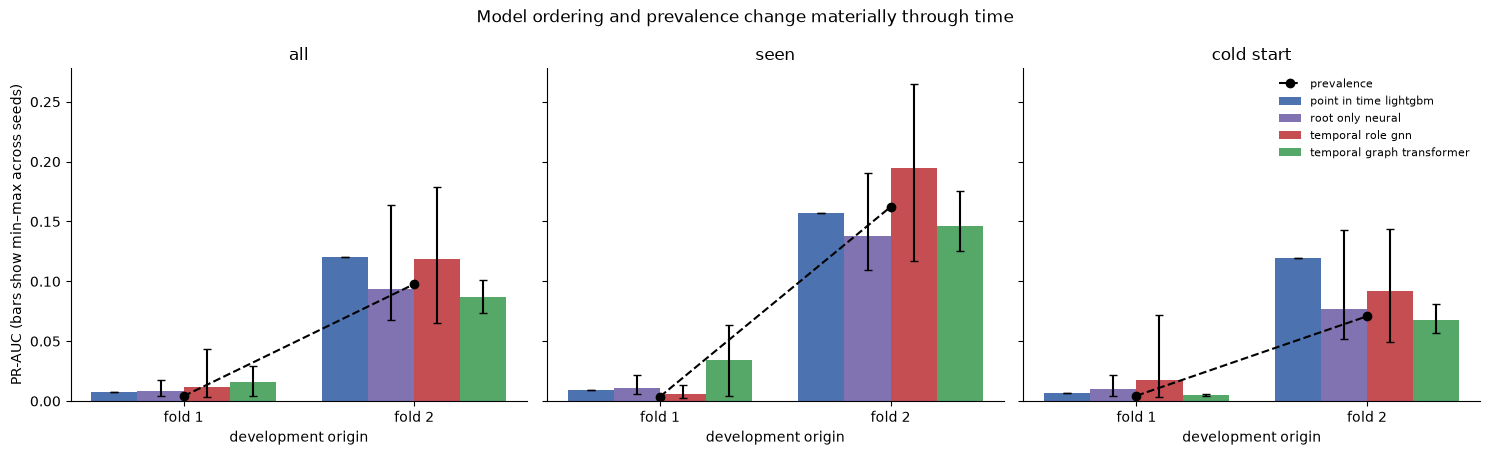

In [4]:
backtest = pd.read_csv(RESULTS / 'temporal_backtest_p90_summary.csv')
plot_backtest_pr_auc(backtest)
plt.show()

The development folds add the fairest four-family comparison. In fold 2, LightGBM and the temporal GNN are tied overall (0.120 and 0.119); the GNN leads for seen companies (0.194), while LightGBM leads cold-start (0.119). The Transformer is strongest only in one narrow regime: sparse fold-1 seen companies. Model ordering changes with prevalence and time, so the evidence supports a **portfolio of hypotheses**, not a universal winner.

## 2. What an ablation can establish

An **ablation** changes one component while holding the rest of the experiment fixed. Here every variant uses identical causal K=8 histories, relation encodings, hidden width, four heads, optimization settings, and paired seeds. Only event age changes:

- **No age:** attention sees content and relation but not recency.
- **Fixed decay:** each legal attention logit receives $-\log(2)\,\Delta t/180$. After 180 days, otherwise equal evidence has half the unnormalized attention mass. This is a prior, not a learned feature.
- **Learned log-age:** the original MLP maps $\log(1+\Delta t)$ into the key/value representation. It is flexible but must estimate more behaviour from rare positives.

The same modules are instantiated in every variant so paired seeds initialize all shared active parameters identically. Fold 1 has 39,361 parameters and fold 2 has 39,745 because fold-fitted categorical vocabularies differ—not because the variants have different budgets. The comparison uses validation PR-AUC only; development-test and sealed-holdout labels do not select the treatment.

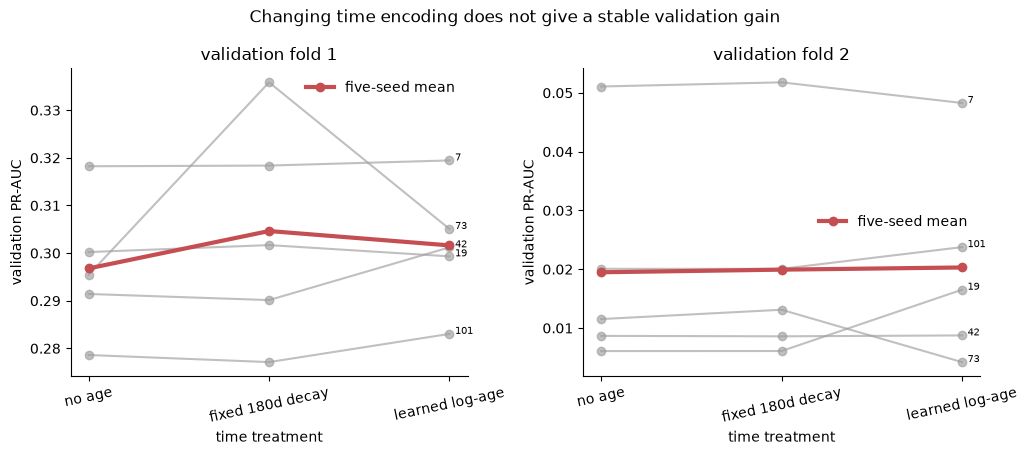

fold,time_encoding,mean,std,min,max
1,fixed_decay,0.3046,0.0231,0.2771,0.3359
1,learned,0.3016,0.0130,0.2830,0.3195
1,none,0.2968,0.0144,0.2786,0.3182
2,fixed_decay,0.0199,0.0186,0.0061,0.0518
2,learned,0.0203,0.0173,0.0042,0.0483
2,none,0.0195,0.0184,0.0061,0.0511


In [5]:
time_ablation = pd.read_csv(RESULTS / 'temporal_transformer_time_ablation.csv')
plot_paired_time_ablation(time_ablation)
plt.show()
time_summary = time_ablation.groupby(['fold', 'time_encoding'])['validation_pr_auc'].agg(
    ['mean', 'std', 'min', 'max']
).reset_index()
display(time_summary.style.format({name: '{:.4f}' for name in ('mean', 'std', 'min', 'max')}).hide(axis='index'))

The grey lines pair the same initialization across treatments; the red line is the five-seed mean. Fixed decay is 0.0030 above learned time in fold 1 but 0.0004 below it in fold 2. Removing age is slightly worse on both means, yet the difference is small relative to seed spread. This is a **negative result**: age contains some useful inductive bias, but neither the flexible encoder nor the 180-day prior explains the Transformer's unstable model ordering. We keep learned time as the default because fixed decay does not improve both origins.

The next validation-only ablation therefore addresses **root/message fusion**. The original residual always adds the attention message at full strength whenever history exists.

## 3. Can history coverage control message strength?

The coverage gate computes one scalar $g_i$ from the current root representation and the fraction of occupied K=8 slots in each relation. Fusion becomes $\operatorname{LayerNorm}(r_i + g_i m_i)$ with $0\le g_i\le1$; the residual control fixes $g_i=1$. A scalar gate is deliberately easier to estimate than one gate per hidden channel. It can suppress questionable context but cannot amplify it beyond the original message. Empty history remains exactly root-only because $m_i=0$.

The dormant gate is instantiated in both treatments while preserving PyTorch's random stream, so the residual control exactly reproduces the earlier learned-time epochs and PR-AUC values. This matters because merely allocating a random layer can otherwise change later dropout masks even when that layer is unused.

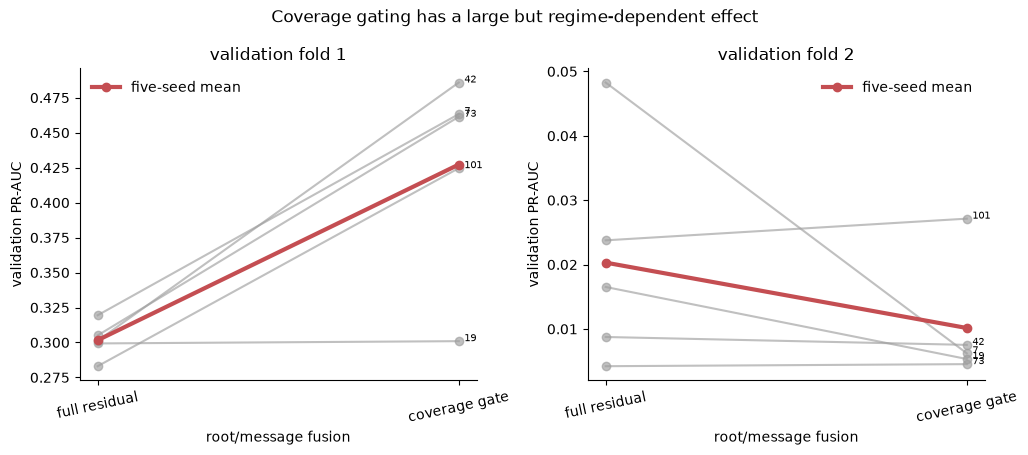

fold,fusion,mean,std,min,max
1,coverage_gate,0.4272,0.0739,0.3009,0.4859
1,residual,0.3016,0.0130,0.2830,0.3195
2,coverage_gate,0.0101,0.0096,0.0045,0.0271
2,residual,0.0203,0.0173,0.0042,0.0483


In [6]:
fusion_ablation = pd.read_csv(RESULTS / 'temporal_transformer_fusion_ablation.csv')
plot_paired_fusion_ablation(fusion_ablation)
plt.show()
fusion_summary = fusion_ablation.groupby(['fold', 'fusion'])['validation_pr_auc'].agg(
    ['mean', 'std', 'min', 'max']
).reset_index()
display(fusion_summary.style.format({name: '{:.4f}' for name in ('mean', 'std', 'min', 'max')}).hide(axis='index'))

Coverage gating has a large effect, but not a stable improvement. Fold 1 rises from 0.3016 to 0.4272 mean validation PR-AUC, with four seeds above 0.42. Fold 2 falls from 0.0203 to 0.0101 and usually stops after one or two epochs. The sign reversal rejects promotion of this gate. It also teaches an important experimental principle: a large effect in one origin can be a regime-specific interaction rather than a generally better architecture.

The evidence now points away from a single flexible learned gate. A lower-variance next control is **capacity and regularization** under the unchanged learned-time residual.

## 4. A 2×2 capacity and regularization experiment

A **factorial design** varies two factors in every combination. Width is 64 (wide) or 32 (compact). Regularization is the current dropout 0.20 plus weight decay $10^{-4}$, or a stronger bundle of dropout 0.35 plus weight decay $10^{-3}$. This answers three questions with four treatments: the main effect of width, the main effect of the regularization bundle, and whether their combination behaves differently.

The compact model has about 10.5k parameters versus 39.4k for the wide model. Seeds remain paired, but parameters of different shapes cannot have one-to-one identical initial values. Strong-regularization pairs at the same width do share initial weights; only training-time dropout and weight decay differ. Because dropout and weight decay move together, a winning bundle would require a later separating ablation before claiming which mechanism helped.

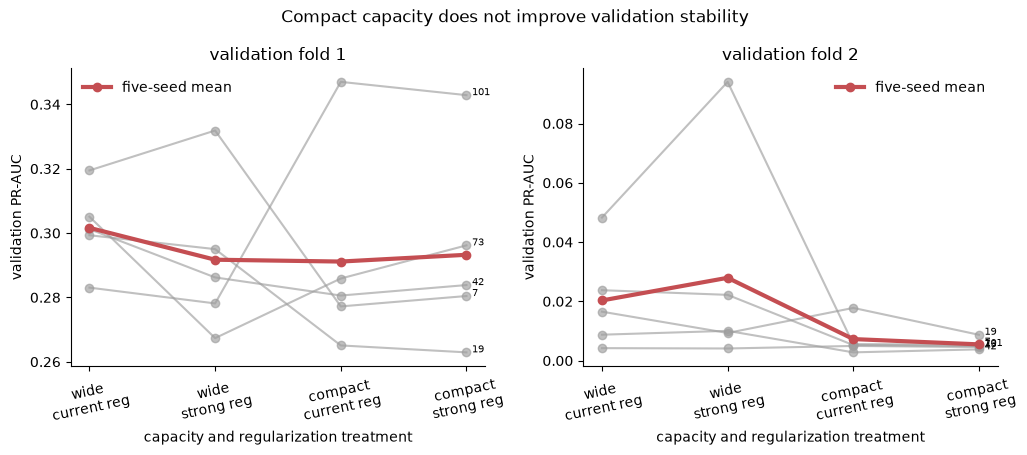

fold,variant,mean,median,std,min,max
1,compact_current,0.2911,0.2806,0.0321,0.2651,0.3470
1,compact_strong_reg,0.2932,0.2838,0.0302,0.2629,0.3429
1,wide_current,0.3016,0.3012,0.0130,0.2830,0.3195
1,wide_strong_reg,0.2917,0.2862,0.0247,0.2673,0.3319
2,compact_current,0.0073,0.0052,0.0060,0.0028,0.0178
2,compact_strong_reg,0.0055,0.0049,0.0019,0.0038,0.0087
2,wide_current,0.0203,0.0165,0.0173,0.0042,0.0483
2,wide_strong_reg,0.0279,0.0100,0.0375,0.0041,0.0941


In [7]:
capacity_ablation = pd.read_csv(RESULTS / 'temporal_transformer_capacity_ablation.csv')
plot_paired_capacity_ablation(capacity_ablation)
plt.show()
capacity_summary = capacity_ablation.groupby(['fold', 'variant'])['validation_pr_auc'].agg(
    ['mean', 'median', 'std', 'min', 'max']
).reset_index()
display(capacity_summary.style.format({
    name: '{:.4f}' for name in ('mean', 'median', 'std', 'min', 'max')
}).hide(axis='index'))

The current wide model remains best in fold 1 at 0.3016 mean. Compact treatments fall to 0.2911–0.2932 and become more seed-variable. In fold 2, wide strong regularization has a nominal mean of 0.0279 versus 0.0203, but one seed at 0.0941 creates that ordering; its median is only 0.0100. Compact models fall to 0.0073 and 0.0055.

This is another negative promotion result. The Transformer is not simply too wide, and the stronger regularization bundle does not improve both origins or most paired seeds. The wide current configuration remains frozen.

## 5. K is an information and compute budget

K limits how many newest strictly-prior events each of four relations may retain. Smaller K emphasizes recency, discards more legal history, and saves memory; larger K offers a longer context but makes attention choose among more possibly stale events. This does not change trainable parameter count because attention projections are shared across slots. It does change the input tensor approximately linearly: with 12 event features, K=2 uses 27.8 MiB and K=16 uses 222.7 MiB.

The cap statistic below is relation-level. ‘Share at cap’ means that relation had at least K legal events and therefore would have retained more if the budget allowed it. Empty and short histories remain included in the denominator.

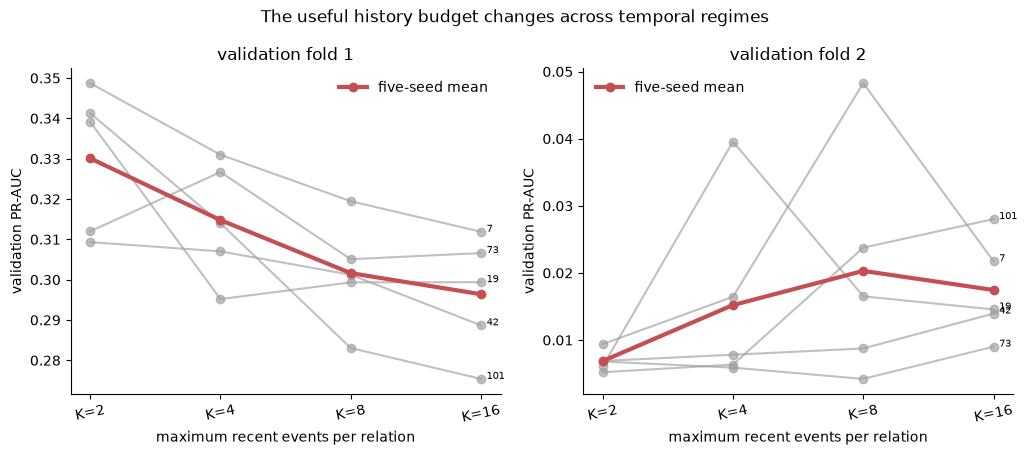

fold,max_events,mean,median,std,min,max
1,2,0.3301,0.3392,0.0181,0.3093,0.3487
1,4,0.3148,0.3140,0.0146,0.2952,0.3310
1,8,0.3016,0.3012,0.0130,0.2830,0.3195
1,16,0.2964,0.2994,0.0146,0.2754,0.3119
2,2,0.0069,0.0068,0.0016,0.0052,0.0094
2,4,0.0152,0.0078,0.0143,0.0059,0.0396
2,8,0.0203,0.0165,0.0173,0.0042,0.0483
2,16,0.0175,0.0146,0.0074,0.0090,0.0280


fold,max_events,mean_events_per_relation,share_relation_histories_at_cap,approx_tensor_mib_f12
1,2,0.79,38.8%,27.8
1,4,1.52,36.1%,55.7
1,8,2.83,31.3%,111.4
1,16,5.00,24.1%,222.7
2,2,0.97,48.2%,27.8
2,4,1.91,46.6%,55.7
2,8,3.70,43.8%,111.4
2,16,7.01,39.8%,222.7


In [8]:
k_ablation = pd.read_csv(RESULTS / 'temporal_transformer_k_ablation.csv')
k_coverage = pd.read_csv(RESULTS / 'temporal_transformer_k_coverage.csv')
plot_paired_k_ablation(k_ablation)
plt.show()
k_summary = k_ablation.groupby(['fold', 'max_events'])['validation_pr_auc'].agg(
    ['mean', 'median', 'std', 'min', 'max']
).reset_index()
display(k_summary.style.format({name: '{:.4f}' for name in ('mean', 'median', 'std', 'min', 'max')}).hide(axis='index'))
display(k_coverage.style.format({
    'mean_events_per_relation': '{:.2f}',
    'share_relation_histories_at_cap': '{:.1%}',
    'approx_tensor_mib_f12': '{:.1f}',
}).hide(axis='index'))

The preferred history budget reverses. Fold 1 improves monotonically as K shrinks: K=2 averages 0.3301 versus 0.3016 at K=8 and 0.2964 at K=16. Fold 2 needs more context: K=2 collapses to 0.0069, K=8 has the highest mean at 0.0203, and K=16 has a 0.0175 mean with a less extreme seed range. The later fold also has more dense histories—at K=8, 43.8% of relation histories hit the cap versus 31.3% in fold 1.

There is no globally optimal fixed K in these origins. Choosing K=2 would tune to the sparse regime and damage the later one; choosing K=16 doubles K=8 memory without improving either mean. K=8 remains the frozen compromise because it leads the later, higher-support fold and was the predeclared candidate—not because it wins every period. Adaptive history budgets would be a new architecture family and are not justified before adding more temporal origins.

## Takeaways

1. Retrospective impairment and causal p90 results answer different questions and need separate scoreboards.
2. LightGBM remains the most stable overall/cold-start benchmark; the temporal GNN has the strongest later-fold seen-company result.
3. The Transformer helps one sparse seen-company regime but is not a stable winner.
4. Learned, fixed, and absent age treatments are nearly tied on paired validation seeds, so time encoding is not the main bottleneck.
5. Coverage gating helps dramatically in one origin and harms the next; a large effect is not a robust win.
6. Compact capacity is weaker, while stronger regularization has one fold-2 outlier rather than a stable gain.
7. K=2 helps the sparse fold but collapses the later fold; K=8 remains a predeclared compromise.
8. The planned Transformer component-ablation sequence is complete without a robust challenger to the default.